In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df  = pd.read_csv("Wholesale_customers_data.csv")
print(df.head())

print(df.shape)
print(df.info())
print(df.isnull().sum())


   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
(440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Del

In [5]:
df.isnull().sum()



Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

##### EDA

In [4]:
df = df.drop_duplicates()

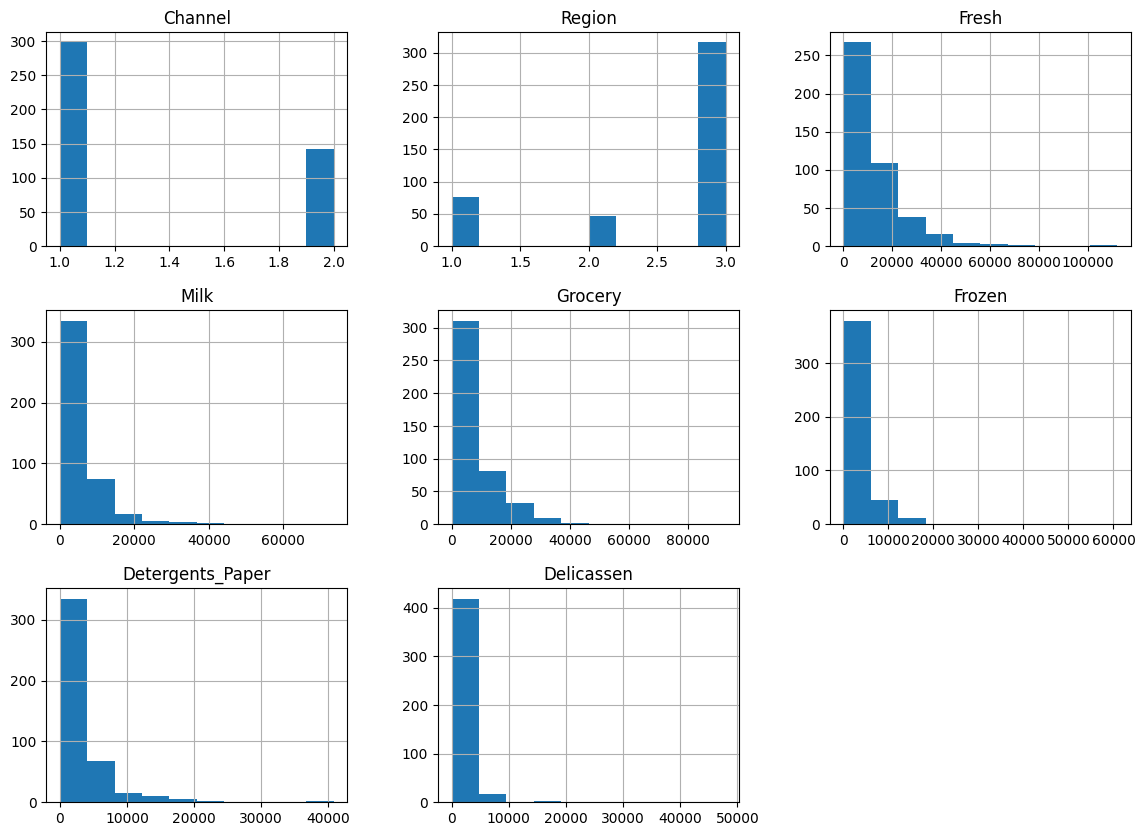

In [3]:

# 11. Histograms


df.hist(figsize=(14,10))

plt.show()

#### BoxPlots

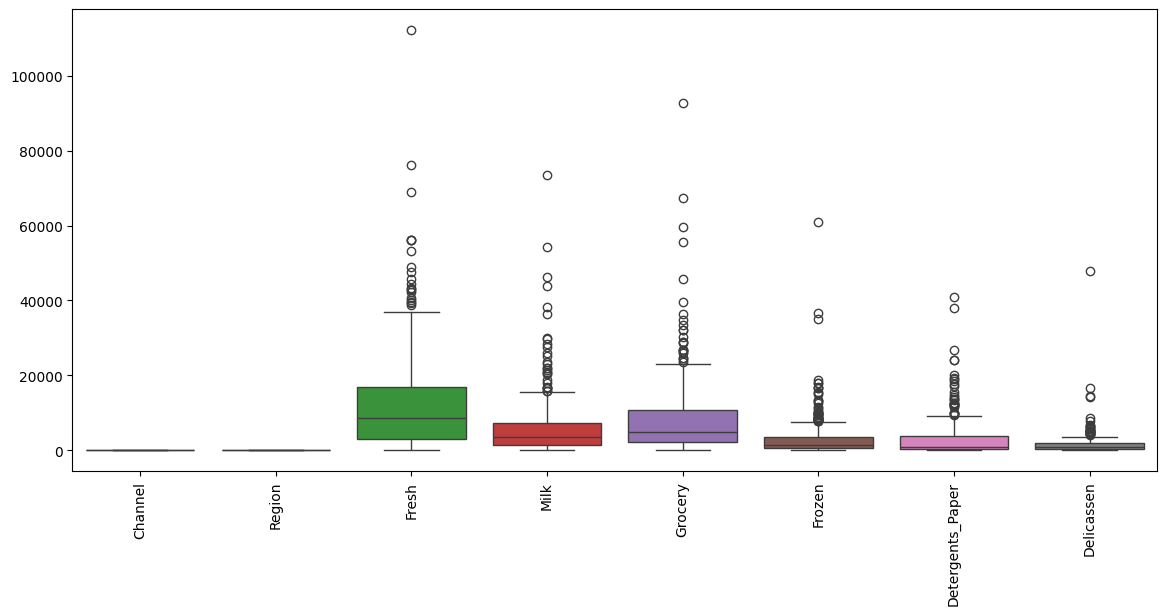

In [5]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

#### `Correlation heat  map

### 

<Axes: >

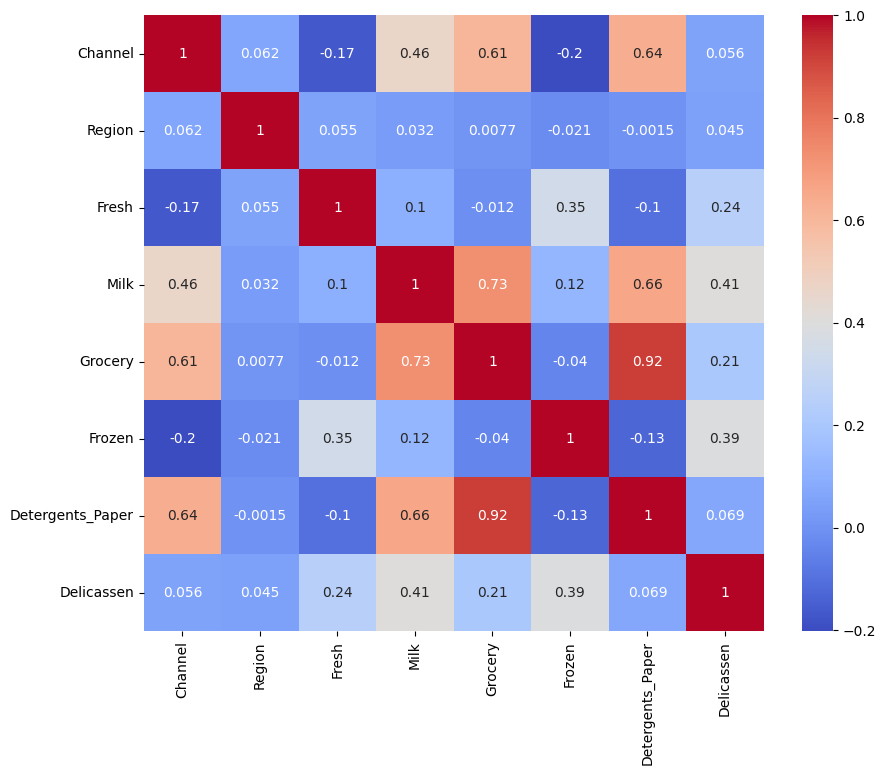

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')



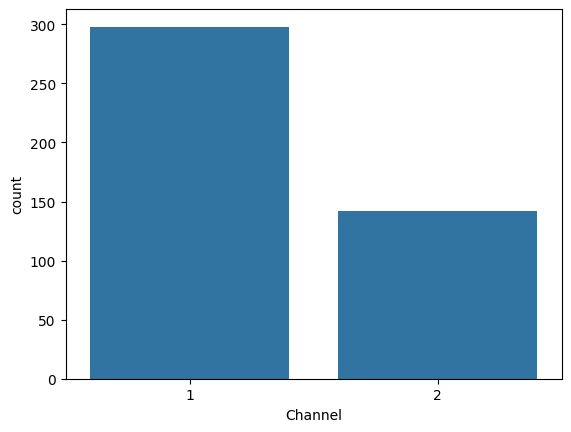

Axes(0.125,0.11;0.775x0.77)


In [9]:
CNT = sns.countplot(x='Channel', data=df)

plt.show()
print(CNT)

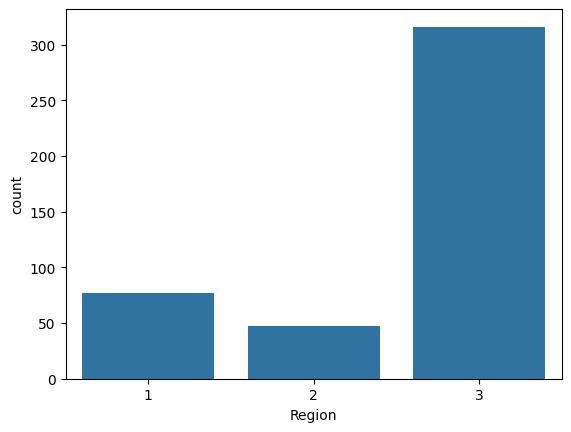

In [10]:
sns.countplot(x='Region', data=df)

plt.show()

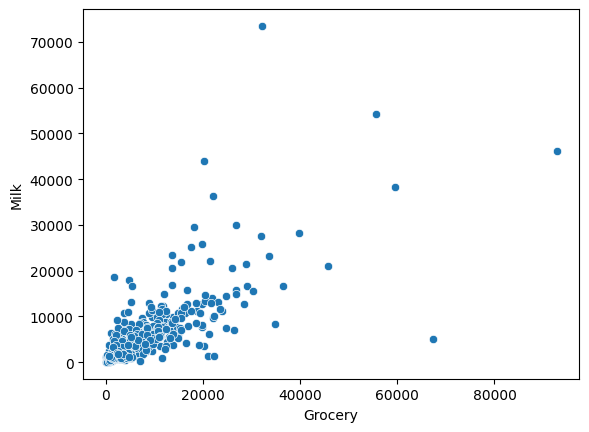

In [11]:
sns.scatterplot(
    x='Grocery',
    y='Milk',
    data=df
)

plt.show()

##### dATA PREPROCESSING

In [12]:

# 19. Log Transformation


df_log = df.copy()

spending_cols = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]

df_log[spending_cols] = np.log1p(
    df_log[spending_cols]
)

##### fEATURE CALLING

In [14]:
X = df_log.drop(
    ['Channel', 'Region'],
    axis=1
)

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### k mEANS

In [18]:

# 22. Elbow Method


wcss = []

for i in range(2,11):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

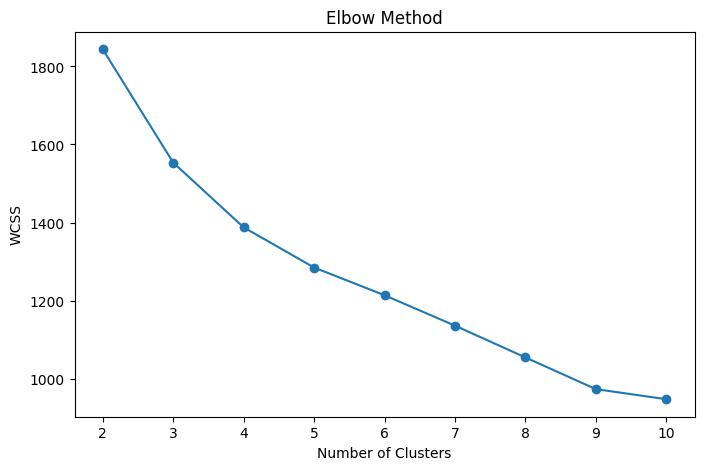

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [20]:
for k in range(2,11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    labels = kmeans.fit_predict(
        X_scaled
    )
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    print(
        "K =", k,
        "Silhouette Score =", score
    )

K = 2 Silhouette Score = 0.2904884403725676
K = 3 Silhouette Score = 0.2607155784408494
K = 4 Silhouette Score = 0.18514346533341078
K = 5 Silhouette Score = 0.19165609775268222
K = 6 Silhouette Score = 0.17762325479526006
K = 7 Silhouette Score = 0.16877431378639335
K = 8 Silhouette Score = 0.19708350389592988
K = 9 Silhouette Score = 0.19650108536770935
K = 10 Silhouette Score = 0.19599855929618182


In [21]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

In [22]:
df['KMeans_Cluster'] = kmeans_labels

##### HIERARCHICAL CLUSTERING

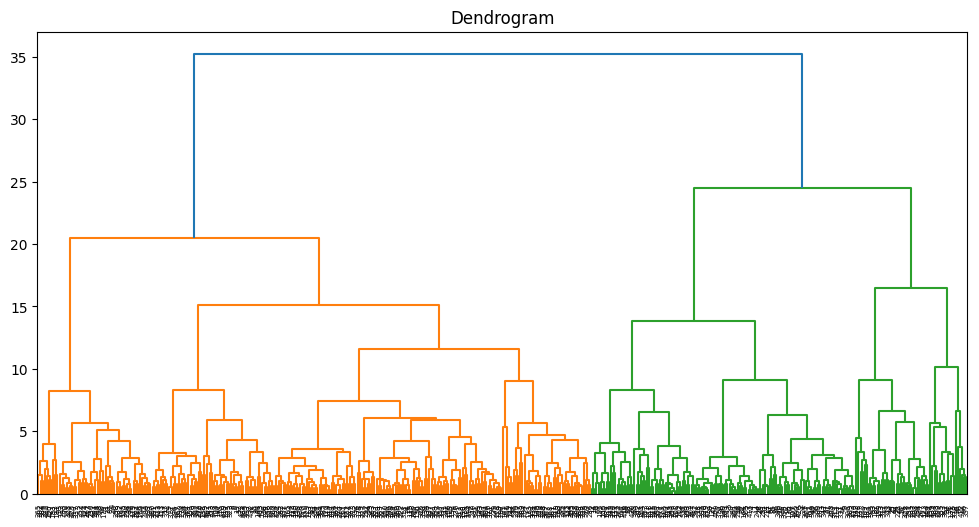

In [23]:

# 27. Create Dendrogram


linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")

plt.show()

In [26]:
hc = AgglomerativeClustering(
    n_clusters=3
)

hc_labels = hc.fit_predict(
    X_scaled
)
df['Hierarchical_Cluster'] = hc_labels

#### DBSCAN CLUSTERING

In [28]:

# 30. Train DBSCAN Model


dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)
df['DBSCAN_Cluster'] = dbscan_labels

##### PCA VISUALIZATION

In [29]:

# 32. Apply PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    X_scaled
)

In [30]:
pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = kmeans_labels

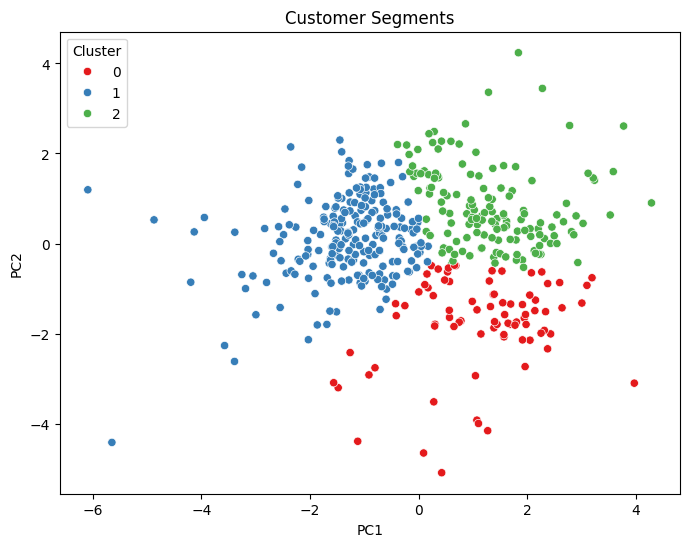

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("Customer Segments")

plt.show()

##### CLUSTER PROFILING

In [33]:

# 35. Cluster Counts


df['KMeans_Cluster'].value_counts()

cluster_profile = df.groupby(
    'KMeans_Cluster'
).mean()

cluster_profile

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Hierarchical_Cluster,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,1.580247,2.530864,2809.444444,6945.901235,12232.567901,588.123457,5382.851852,782.345679,1.271605,-0.185185
1,1.013889,2.500000,12399.537037,2087.828704,2554.074074,3286.509259,427.435185,919.439815,0.046296,-0.092593
2,1.643357,2.615385,16603.258741,10746.629371,13678.629371,4154.727273,5171.468531,2859.958042,1.328671,-0.041958


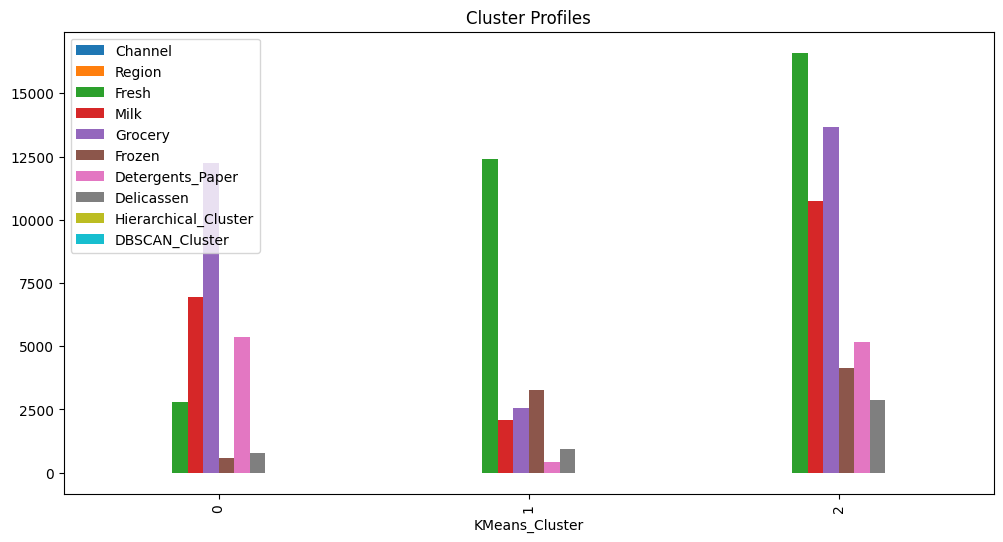

In [34]:
cluster_profile.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Cluster Profiles")

plt.show()


# 38. Example Business Interpretation

```python
"""
Cluster 0:
High Grocery and Detergents buyers

Cluster 1:
Fresh food oriented customers

Cluster 2:
Low spending customers
"""

In [35]:
df.to_csv(
    "clustered_customers.csv",
    index=False
)